# Домашнее задание 2 (13 pts)


## Задача 1 (5 pts)

1. (1 pts) Найди градиент $f'(\mathbf{x})$ и гессиан $f''(\mathbf{x})$, если

$$ f(\mathbf{x}) = \frac{1}{2}\Vert A - \mathbf{x} \mathbf{x}^T\Vert ^2_F,$$

где $A \in \mathbb{S}^n$.

2. (2 pts) Найди градиент $f'(\mathbf{x})$ и гессиан $f''(\mathbf{x})$, если
  $$
   f(\mathbf{x}) = \frac{1}{m} \sum\limits_{i\ =\ 1}^m \log \bigl( 1 + \exp(\mathbf{a}_i^{\top}\mathbf{x}) \bigr) + \frac{\mu}{2} \, \Vert \mathbf{x}\Vert _2^2,\; \mathbf{a}_i, \mathbf{x} \in \mathbb R^n,\; \mu>0.
   $$

3. (2 pts) Найди градиент $f'$ по $\mathbf{U}$ и по $\mathbf{V}$, если

$$ f(\mathbf{U}, \mathbf{V}) = \frac12 \| \mathbf{X} - \mathbf{U}\mathbf{V}^\top \|_F^2. $$


Решение 1. (1 pts) Найди градиент $f'(\mathbf{x})$ и гессиан $f''(\mathbf{x})$, если

$$ f(\mathbf{x}) = \frac{1}{2}\Vert A - \mathbf{x} \mathbf{x}^T\Vert ^2_F,$$

Вначале упростим f(x) заменив A-X*X.T на B
тогда получим $$ f(\mathbf{x}) = \frac{1}{2}\Vert B \Vert ^2_F$$

так как $$\|B\|_F^2 = \text{Tr}(B^T B)$$ получим 
$$ f(\mathbf{x}) =  \frac{1}{2}\| A - \mathbf{x}\mathbf{x}^{T} \|_{F}^{2} = \frac{1}{2} \text{Tr}\left( (A - \mathbf{x}\mathbf{x}^{T})^{T} (A - \mathbf{x}\mathbf{x}^{T}) \right)$$


$$ \text{Tr}(B) = \text{Tr}(B^T)$$

значит

$$f(\mathbf{x})=\frac{1}{2}\text{Tr}(A^{T}A)-\frac{1}{2}\text{Tr}(A^{T}\mathbf{xx}^{T})-\frac{1}{2}\text{Tr}(\mathbf{xx}^{T}A)+\frac{1}{2}\text{Tr}(\mathbf{xx}^{T}\mathbf{xx}^{T})=$$

$$f(\mathbf{x})=\frac{1}{2}\|{}A\|{}_{F}^{2}-\frac{1}{2}\mathbf{x}^{T}(A+A^{T})\mathbf{x}+\frac{1}{2}\|{}\mathbf{x}\|{}^{4}$$

$$ Ищем    f'(\mathbf{x})$$
$$

df = 0 -\frac{1}{2} \cdot 2\mathbf{x}^{T}(A+A^{T})d\mathbf{x} + \frac{1}{2} \cdot 2\|\mathbf{x}\|^{2} \cdot 2\mathbf{x}^{T}d\mathbf{x}

$$

$$ df = \left(2\|\mathbf{x}\|^{2}\mathbf{x} - (A+A^{T})\mathbf{x}\right)^{T}d\mathbf{x} $$

Так как $$ df = \langle \nabla f(\mathbf{x}), d\mathbf{x} \rangle = (f'(\mathbf{x}))^T d\mathbf{x}$$

$$ f^{\prime }(\mathbf{x}) = 2\|\mathbf{x}\|^{2}\mathbf{x} - (A+A^{T})\mathbf{x} $$


Ищем гессиану
$$   f''(\mathbf{x}) $$

$$ d(f^{\prime }(\mathbf{x}))=d(2\|{}\mathbf{x}\|{}^{2}\mathbf{x})-d((A+A^{T})\mathbf{x})$$

$$ d(f^{\prime }(\mathbf{x}))=2\cdot d(\|{}\mathbf{x}\|{}^{2})\mathbf{x}+2\|{}\mathbf{x}\|{}^{2}d\mathbf{x}-(A+A^{T})d\mathbf{x} $$

Заменим  $$ d(\Vert{}\mathbf{x}\Vert{}^2 = 2\mathbf{x}^T d\mathbf{x} : $$

$$ d(f^{\prime }(\mathbf{x}))=4(\mathbf{x}^{T}d\mathbf{x})\mathbf{x}+2\|{}\mathbf{x}\|{}^{2}d\mathbf{x}-(A+A^{T})d\mathbf{x} $$

Так как  $$ (\mathbf{x}^T d\mathbf{x})\mathbf{x} = \mathbf{x}(\mathbf{x}^T d\mathbf{x}) = (\mathbf{x}\mathbf{x}^T)d\mathbf{x} $$

$$ d(f^{\prime }(\mathbf{x}))=\left(4\mathbf{xx}^{T}+2\|{}\mathbf{x}\|{}^{2}I-(A+A^{T})\right)d\mathbf{x} $$

Ответ: $$f^{\prime \prime }(\mathbf{x})=4\mathbf{xx}^{T}+2\|{}\mathbf{x}\|{}^{2}I-(A+A^{T}) $$

## Задача 2 (4 pts)

В методе Брента вершина параболы $u$ принимается, только если выполнены **оба** условия безопасности:

1. $u$ лежит строго внутри текущего отрезка неопределённости;
2. $|u - x| < \tfrac12 |e|$, где $e$ — смещение на шаге *перед предыдущим*.

**Задание.**

1. (2 pts) Реализуй метод Брента и его модификацию, в которой **отключено только второе** условие (первое оставь).


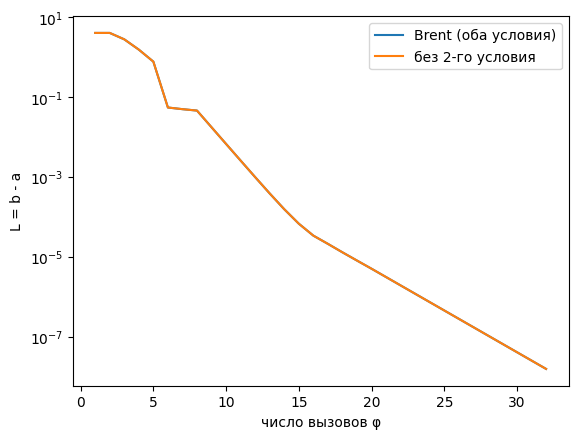

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def parabolic_vertex(v, fv, w, fw, x, fx):
    """Вершина параболы через (v, fv), (w, fw), (x, fx).
    Верни u или None, если точки почти солинейны/совпадают.
    """
    # Подсказка: используй ту же формулу, что на слайдах (через x как опорную точку),
    # либо u = -b/(2a) для p(t) = a t^2 + b t + c
    # TODO: реализуй
    # Проверка на совпадение точек по абсциссе
    if np.isclose(x, v) or np.isclose(x, w) or np.isclose(v, w):
        return None

    # Численно устойчивая схема интерполяции относительно x
    p = (x - v) ** 2 * (fx - fw) - (x - w) ** 2 * (fx - fv)
    q = 2 * ((x - v) * (fx - fw) - (x - w) * (fx - fv))

    if np.isclose(q, 0.0):
        return None

    u = x - p / q
    return u


def brent(phi, a, b, eps=1e-8, use_second_safety=True, max_evals=10_000):
    """Метод Брента на [a, b].

    Параметры
    ---------
    use_second_safety : bool
        True  — классический метод Брента.
        False — только первое условие выполняется: u строго внутри (a, b).

    Возвращает
    ----------
    x_star : float
    n_evals : int
    history : dict с ключами
        'L' — список длин отрезка b-a после каждого вызова phi (или после итерации).
        'evals' — список кумулятивного числа вызовов.
    """

    n_evals = 0
    history = {"L": [], "evals": []}

    def eval_phi(t):
        nonlocal n_evals
        n_evals += 1
        val = phi(t)
        history["L"].append(b - a)
        history["evals"].append(n_evals)
        return val

    # --- инициализация (как на слайдах) ---
    x = 0.5 * (a + b)
    fx = eval_phi(x)
    w = v = x
    fw = fv = fx
    e = 0.0  # предпоследнее смещение
    d = 0.0  # последнее смещение

    while (b - a) > eps and n_evals < max_evals:
        # 1) кандидат параболы
        u = parabolic_vertex(v, fv, w, fw, x, fx)

        # 2) условия
        accept_parabola = (
            u is not None
            and (a < u < b)
            # TODO: второе условие — учитывай флаг use_second_safety
            # Если флаг выключен, правая часть `or` даже не проверяется
            and (not use_second_safety or abs(u - x) < 0.5 * abs(e))
        )

        if accept_parabola:
            pass  # u уже задан
        else:
            # шаг золотого сечения в большую половину
            # TODO
            tau = (np.sqrt(5) - 1) / 2
            if x >= 0.5 * (a + b):
                u = x - (tau**2) * (x - a)
            else:
                u = x + (tau**2) * (b - x)
            #raise NotImplementedError("golden-section fallback")

        # 3) обновить историю смещений и вычислить phi(u)
        e, d = d, u - x
        fu = eval_phi(u)

        # 4) обновить [a, b] и точки v, w, x (x — лучшая)
        # TODO: сохрани отрезок, в котором находится минимум, и упорядочи v, w, x по значениям phi
        if u < x:
            if fu <= fx:
                b = x
                v, fv = w, fw
                w, fw = x, fx
                x, fx = u, fu
            else:
                a = u
                if fu <= fw or np.isclose(w, x):
                    v, fv = w, fw
                    w, fw = u, fu
                elif fu <= fv or np.isclose(v, x) or np.isclose(v, w):
                    v, fv = u, fu
        else:  # u >= x
            if fu <= fx:
                a = x
                v, fv = w, fw
                w, fw = x, fx
                x, fx = u, fu
            else:
                b = u
                if fu <= fw or np.isclose(w, x):
                    v, fv = w, fw
                    w, fw = u, fu
                elif fu <= fv or np.isclose(v, x) or np.isclose(v, w):
                    v, fv = u, fu

    return x, n_evals, history


# Пример использования
x1, n1, h1 = brent(phi, a, b, use_second_safety=True)
x2, n2, h2 = brent(phi, a, b, use_second_safety=False)
plt.semilogy(h1["evals"], h1["L"], label="Brent (оба условия)")
plt.semilogy(h2["evals"], h2["L"], label="без 2-го условия")
plt.xlabel("число вызовов φ"); plt.ylabel("L = b - a"); plt.legend()



__2.__ (1 pts) Подбери унимодальную $\varphi$ с «почти плоским» дном / почти линейным участком, на которой полная версия Брента сокращает $L_k$, а версия без второго условия делает серию всё более мелких шагов и почти не сжимает отрезок. Построй график $L_k$ в логарифмическом масштабе от числа вызовов $\varphi$ для обеих версий.

__3.__ (1 pts) Кратко объясни, почему второе условие исправляет такую патологию и в какой ситуации первое условие выполнено, а второе — нет (на твоём примере).


full Brent:      x = 0.9010266094265869 evals = 54 last L = 1.1206247041428696e-10
without safety:  x = 0.8997624699084146 evals = 59 last L = 1.3116840946736374e-10


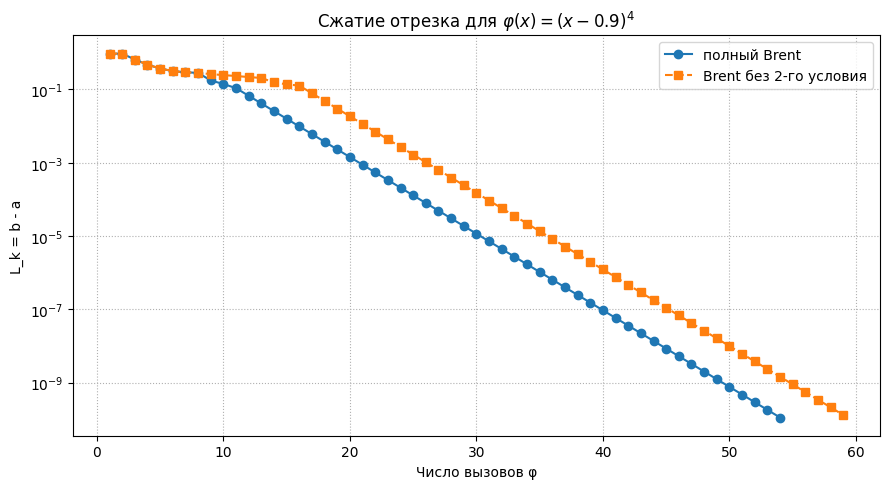

In [41]:
import numpy as np
import matplotlib.pyplot as plt


def parabolic_vertex(v, fv, w, fw, x, fx):
    if np.isclose(x, v) or np.isclose(x, w) or np.isclose(v, w):
        return None

    p = (x - v) ** 2 * (fx - fw) - (x - w) ** 2 * (fx - fv)
    q = 2 * ((x - v) * (fx - fw) - (x - w) * (fx - fv))

    if np.isclose(q, 0.0):
        return None

    u = x - p / q
    return u


def brent(phi, a, b, eps=1e-8, use_second_safety=True, max_evals=10_000):
    n_evals = 0
    history = {"L": [], "evals": []}

    def eval_phi(t):
        nonlocal n_evals
        n_evals += 1
        val = phi(t)
        history["L"].append(b - a)
        history["evals"].append(n_evals)
        return val

    x = 0.5 * (a + b)
    fx = eval_phi(x)

    w = v = x
    fw = fv = fx
    e = 0.0
    d = 0.0

    while (b - a) > eps and n_evals < max_evals:
        u = parabolic_vertex(v, fv, w, fw, x, fx)

        accept_parabola = (
            u is not None
            and (a < u < b)
            and (not use_second_safety or abs(u - x) < 0.5 * abs(e))
        )

        if accept_parabola:
            pass
        else:
            tau = (np.sqrt(5.0) - 1.0) / 2.0
            if x >= 0.5 * (a + b):
                u = x - (tau ** 2) * (x - a)
            else:
                u = x + (tau ** 2) * (b - x)

        e, d = d, u - x
        fu = eval_phi(u)

        if u < x:
            if fu <= fx:
                b = x
                v, fv = w, fw
                w, fw = x, fx
                x, fx = u, fu
            else:
                a = u
                if fu <= fw or np.isclose(w, x):
                    v, fv = w, fw
                    w, fw = u, fu
                elif fu <= fv or np.isclose(v, x) or np.isclose(v, w):
                    v, fv = u, fu
        else:
            if fu <= fx:
                a = x
                v, fv = w, fw
                w, fw = x, fx
                x, fx = u, fu
            else:
                b = u
                if fu <= fw or np.isclose(w, x):
                    v, fv = w, fw
                    w, fw = u, fu
                elif fu <= fv or np.isclose(v, x) or np.isclose(v, w):
                    v, fv = u, fu

    return x, n_evals, history


# --- подопытная функция ---
#phi = lambda x: (x - 0.9) ** 4
phi = lambda x: 1e-6 + (x - 0.9) ** 8
#a, b = 0.0, 1.0
a, b = 0.0, 0.95

x_full, n_full, h_full = brent(
    phi, a, b, eps=1e-10, use_second_safety=True, max_evals=500
)
x_no, n_no, h_no = brent(
    phi, a, b, eps=1e-10, use_second_safety=False, max_evals=500
)

print("full Brent:      x =", x_full, "evals =", n_full, "last L =", h_full["L"][-1])
print("without safety:  x =", x_no,   "evals =", n_no,   "last L =", h_no["L"][-1])

plt.figure(figsize=(9, 5))
plt.semilogy(h_full["evals"], h_full["L"], "o-", label="полный Brent")
plt.semilogy(h_no["evals"], h_no["L"], "s--", label="Brent без 2-го условия")
plt.xlabel("Число вызовов φ")
plt.ylabel("L_k = b - a")
plt.title(r"Сжатие отрезка для $\varphi(x)=(x-0.9)^4$")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

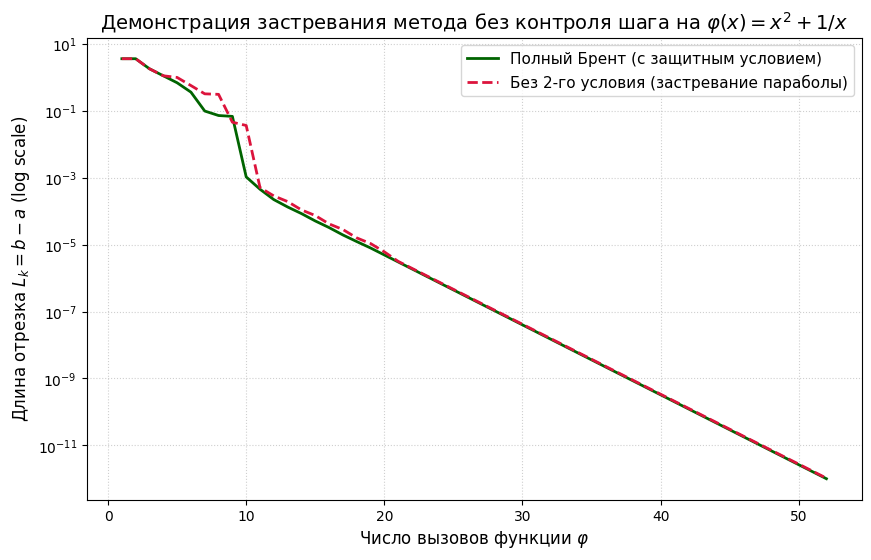

In [32]:
import matplotlib.pyplot as plt
import numpy as np


# --- Целевая функция и отрезок, гарантирующие застревание параболы ---
def phi(x):
    return x**2 + 1.0 / x


# Сильно асимметричный интервал относительно минимума (~0.79)
a, b = 0.4, 4.0

# Запускаем вычисления
x1, n1, h1 = brent(
    phi, a, b, eps=1e-12, use_second_safety=True, max_evals=100
)
x2, n2, h2 = brent(
    phi, a, b, eps=1e-12, use_second_safety=False, max_evals=100
)

# --- График ---
plt.figure(figsize=(10, 6))
plt.semilogy(
    h1["evals"],
    h1["L"],
    label="Полный Брент (с защитным условием)",
    color="darkgreen",
    linewidth=2,
)
plt.semilogy(
    h2["evals"],
    h2["L"],
    label="Без 2-го условия (застревание параболы)",
    color="crimson",
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Число вызовов функции $\\varphi$", fontsize=12)
plt.ylabel("Длина отрезка $L_k = b - a$ (log scale)", fontsize=12)
plt.title(
    "Демонстрация застревания метода без контроля шага на $\\varphi(x) = x^2 + 1/x$",
    fontsize=14,
)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.show()


## Задача 3 (4 pts)

Точный одномерный поиск часто встраивают в многомерный метод как линейный поиск.
Например, в каждой итерации градиентного спуска берут направление $\mathbf{d}_k = -f'(\mathbf{x}_k)$ и решают
$$
\min_{\alpha\ \ge\ 0} \varphi(\alpha) = f(\mathbf{x}_k + \alpha \mathbf{d}_k).
$$

**Задание.**

__1.__ (1 pts) Возьми логистическую регрессию из задачи 1.2 на **синтетическом** датасете:
$$
f(\mathbf{x}) = \frac{1}{m} \sum_{i\ =\ 1}^m \log\bigl(1 + \exp(\mathbf{a}_i^\top \mathbf{x})\bigr) + \frac{\mu}{2}\,\Vert\mathbf{x}\Vert_2^2
$$
и реализуй градиентный спуск с **точным** линейным поиском (шаблон кода ниже).
Обрати внимание на устойчивое вычисление используемых величин — см., например, [logaddexp](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html).

In [ ]:
import numpy as np


# --- Логистическая регрессия (как в задаче 1.2) на синтетических данных ---

def make_logistic_regression(m=200, n=20, mu=1e-2, seed=0, separable_noise=0.3):
    """Синтетический датасет и оракулы f, grad_f.

    Возвращает f, grad_f, а также (A, y) на случай, если понадобятся для отладки.
    A — матрица строк a_i^T размера m x n.
    """
    rng = np.random.default_rng(seed)

    # TODO: сгенерируй признаки Z ∈ R^{m×n} и метки y ∈ {-1, +1}
    # Подсказка: w_true = rng.normal(size=n); logits = Z @ w_true;
    #            y = sign(logits + noise), noise ~ N(0, separable_noise^2)
    Z = None  # TODO: shape (m, n)
    y = None  # TODO: shape (m,), values ±1

    # a_i = -y_i z_i  ⇒  строки A
    A = None  # TODO: A = (-y)[:, None] * Z

    def f(x):
        # TODO
        raise NotImplementedError

    def grad_f(x):
        # TODO
        raise NotImplementedError

    return f, grad_f, A, y


def exact_line_search(f, x, d, method="brent", alpha_max=10.0, eps=1e-8):
    """Точный поиск
    method: 'brent' | 'golden'
    Верни alpha_star и число вызовов f вдоль луча.
    """
    n_evals = 0

    def phi(alpha):
        nonlocal n_evals
        n_evals += 1
        return f(x + alpha * d)

    a, b = 0.0, alpha_max
    # TODO: вызови свой brent/golden_section из задачи 2
    #   alpha_star, _, _ = brent(phi, a, b, eps=eps)
    raise NotImplementedError

    return alpha_star, n_evals


def gradient_descent_exact(f, grad_f, x0, eps=1e-6, max_iter=500, ls_method="brent"):
    """Градиентный спуск с точным линейным поиском (пункт 3.1).

    Возвращает
    ----------
    x : np.ndarray
    info : dict с ключами
        'nit'        — число итераций GD.
        'n_evals_f'  — суммарное число вызовов f (в линейном поиске).
        'grad_norms' — список ||f'(x_k)||_2.
    """
    x = np.asarray(x0, dtype=float).copy()
    grad_norms = []
    n_evals_f = 0

    for k in range(max_iter):
        g = grad_f(x)
        gnorm = np.linalg.norm(g)
        grad_norms.append(gnorm)
        if gnorm <= eps:
            break

        d = -g  # направление спуска
        # TODO: alpha, n_ls = exact_line_search(f, x, d, method=ls_method)
        # TODO: x = x + alpha * d ; n_evals_f += n_ls
        raise NotImplementedError

    info = {"nit": k, "n_evals_f": n_evals_f, "grad_norms": grad_norms}
    return x, info


# Пример запуска для 3.1:
# f, grad_f, A, y = make_logistic_regression()
# x0 = np.zeros(A.shape[1])
# x_star, info = gradient_descent_exact(f, grad_f, x0, ls_method="brent")
# print(info["nit"], info["n_evals_f"])

__2.__ (2 pts) Сравни на этой $f$ и одинаковой точке старта $\mathbf{x}_0$ четыре стратегии выбора шага:
   - точный поиск методом золотого сечения;
   - точный поиск методом Брента;
   - постоянный шаг $\alpha_k \equiv \alpha$ (перебери 3 разномасштабных размера шага);
   - неточный поиск: **бэктрекинг с условием Армихо** (см. ниже).

   Для каждой стратегии залогируй число итераций GD до заданной точности (например, $\|f'(\mathbf{x}_k)\|_2 \le \varepsilon$) и **суммарное** число вызовов $f$ (или $\varphi$). Нарисуй графики сходимости: точность $(\|f'(\mathbf{x}_k)\|_2)$ vs число итераций и точность vs время.

### Условие Армихо и бэктрекинг

Пусть $\varphi(\alpha) = f(\mathbf{x} + \alpha \mathbf{d})$, направление спуска $\mathbf{d}$ удовлетворяет $\varphi'(0) = \langle f'(\mathbf{x}), \mathbf{d}\rangle < 0$.

**Условие достаточного убывания (Армихо)** с параметром $c_1 \in (0,1)$ (обычно $c_1 \in [10^{-4},\,10^{-1}]$):
$$
\varphi(\alpha) \le \varphi(0) + c_1 \alpha \, \varphi'(0).
$$
Геометрически: график $\varphi$ должен лежать не выше прямой с наклоном $c_1\varphi'(0)$ (положе, чем касательная в нуле). Так отсекаются шаги со слишком слабым убыванием.

При $\mathbf{d} = -f'(\mathbf{x})$ имеем $\varphi'(0) = -\|f'(\mathbf{x})\|_2^2$, и условие принимает вид
$$
f(\mathbf{x} + \alpha \mathbf{d})
\le
f(\mathbf{x}) - c_1 \alpha \, \|f'(\mathbf{x})\|_2^2.
$$

**Бэктрекинг** реализует Армихо за несколько вызовов $f$:
1. Задать начальный шаг $\alpha \leftarrow \alpha_0 > 0$ и коэффициент дробления $\beta \in (0,1)$ (типично $\beta = 1/2$).
2. Пока условие Армихо **не** выполнено: $\alpha \leftarrow \beta\alpha$.
3. Вернуть первое (самое большое из проверенных) подходящее $\alpha$.



In [ ]:
def armijo_backtracking(f, grad_f, x, d, c1=1e-4, alpha0=1.0, beta=0.5, max_steps=50):
    """Бэктрекинг с условием Армихо.
    """
    # TODO
    raise NotImplementedError

__3.__ (1 pts) На основе построенных графиков прокомментируй, когда точный одномерный поиск окупается, а когда суммарные траты на поиск шага выше, чем у неточного поиска (Армихо).


In [ ]:
# Место для вашего решения